# Climate data pre-preprocessing

Long-term climate data rasters (mean temperature and precipitation) was downloaded from NOAA Monthly U.S. Climate Gridded Dataset (NClimGrid) (https://doi.org/10.7289/V5SX6B56). These rasters contains long-term climate data for the entire US, so they needs to be clipped to the area of interest. The code below loads the downloaded NClimGrid rasters, clips them to the area of interest, i.e. Salt and Verde River watersheds, and then averages (for temperature) or sums (for precipitation) values over each watershed for each month. The output is a csv file with monthly average temperature and monthly total precipitation values for each watershed.

### a. Loading data

Climate data

In [ ]:
#installing packages
#%pip install "xarray[complete]" 
#%pip install "geopandas"
#%pip install "rioxarray"

In [1]:
#loading packages
import pandas as pd
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import json
import numpy as np

In [2]:
#loading NClimGrid rasters
Precip = xr.open_dataset("Data/RawData/nclimgrid_prcp.nc") #precipitation
Temp = xr.open_dataset("Data/RawData/nclimgrid_tavg.nc") #temperature

In [3]:
#accessing the actual data stored in the rasters
Precip = Precip["prcp"]
Temp = Temp["tavg"]

In [4]:
#seeing what the data looks like 
Precip.head()

<xarray.DataArray 'prcp' (time: 5, lat: 5, lon: 5)> Size: 500B
[125 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 40B 1895-01-01 1895-02-01 ... 1895-05-01
  * lat      (lat) float32 20B 49.35 49.31 49.27 49.23 49.19
  * lon      (lon) float32 20B -124.7 -124.6 -124.6 -124.6 -124.5
Attributes:
    references:     GHCN-Monthly Version 3 (Vose et al. 2011), NCEI/NOAA, htt...
    long_name:      Precipitation, monthly total
    standard_name:  precipitation_amount
    units:          millimeter
    valid_min:      0.0
    valid_max:      2000.0

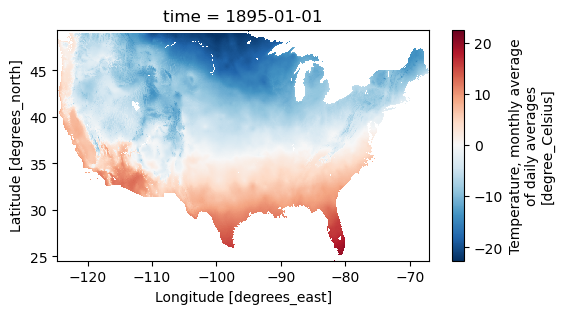

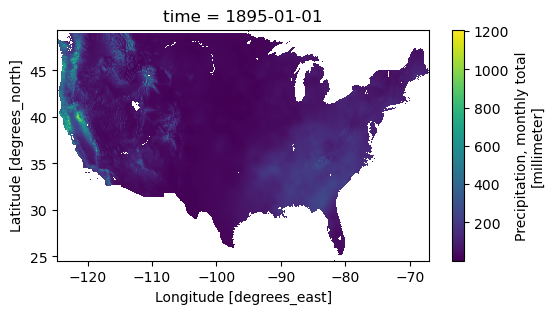

In [5]:
#plotting temperature & precipitation for Jan 1895 (just to get an idea of what the data looks like)
temp1 = Temp.isel(time = 0)
precip1 = Precip.isel(time=0)

plt.figure(figsize=(6,3))
temp1.plot()
plt.show()

plt.figure(figsize=(6,3))
precip1.plot()
plt.show()


Watershed boundaries

In [8]:
#loading watershed boundaries
Salt_boundary = gpd.read_file("Data/RawData/SaltWatershedBoundaries.zip!layers/globalwatershed.shp")
Verde_boundary = gpd.read_file("Data/RawData/VerdeWatershedBoundaries.zip!layers/globalwatershed.shp")

In [7]:
#plotting watershed boundaries (just to check if they loaded correctly)

minx, miny, maxx, maxy = Salt_boundary.total_bounds

center_lon = (minx + maxx) / 2
center_lat = (miny + maxy) / 2

fig = go.Figure()
for gdf, name, color in [
    (Salt_boundary, "Salt", "blue"),
    (Verde_boundary, "Verde", "green")
]:
    gdf = gdf.to_crs(4326)

    for geom in gdf.geometry:
        x, y = geom.exterior.xy

        fig.add_trace(go.Scattermapbox(
            lon=list(x),
            lat=list(y),
            mode="lines",
            name=name,
            line=dict(color=color, width=2)
        ))

fig.update_layout(
    mapbox=dict(
        style="open-street-map",   
        center=dict(lat=center_lat, lon=center_lon),
        zoom=6.5
    ),
    margin=dict(r=0, t=40, l=0, b=0),
    title="Salt & Verde Watersheds")

fig.show()

### b. Clipping climate data to watershed boundaries

First ensuring that spatial coordinates of the rasters are specified (since the rasters have 3 dimensions, i.e. latitude, longitude, and time, Python may get confused about which of these are the spatial coordinates) 

In [9]:
Precip = Precip.rio.set_spatial_dims(x_dim = 'lon', y_dim = 'lat')
Temp = Temp.rio.set_spatial_dims(x_dim = 'lon', y_dim = 'lat')

Also ensuring that all climate rasters and watershed shapefiles have the same CRS

In [10]:
#Checking CRS
print(Salt_boundary.crs) #watershed boundary shapefiles are already in EPSG:4326
print(Verde_boundary.crs) #watershed boundary shapefiles are already in EPSG:4326
print(Precip.rio.crs)
print(Temp.rio.crs)

EPSG:4326
EPSG:4326
None
None


In [11]:
#setting CRS for climate rasters
Precip = Precip.rio.write_crs("EPSG:4326")
Temp = Temp.rio.write_crs("EPSG:4326")

Clipping climate data to watershed boundaries 

In [ ]:
#this part may take time to run

Temp_Salt = Temp.rio.clip(Salt_boundary.geometry, Salt_boundary.crs)
Precip_Salt = Precip.rio.clip(Salt_boundary.geometry, Salt_boundary.crs)

Temp_Verde = Temp.rio.clip(Verde_boundary.geometry, Verde_boundary.crs)
Precip_Verde = Precip.rio.clip(Verde_boundary.geometry, Verde_boundary.crs)

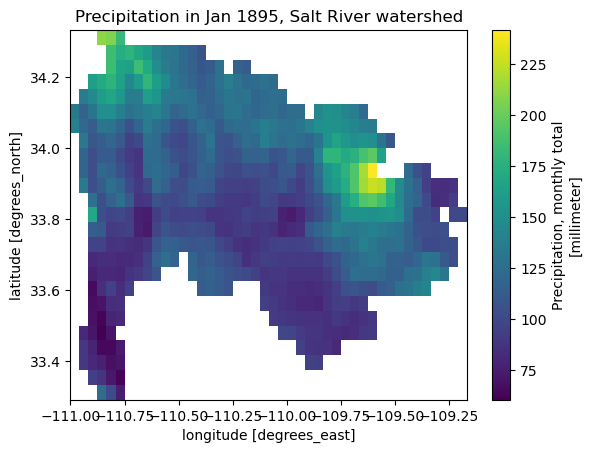

In [ ]:
#plotting one of the clipped rasters (just to see if it looks right)
dat =Precip_Salt.isel(time=0) #filtering to keep only the 1st timepoint
dat.plot()
plt.title("Precipitation in Jan 1895, Salt River watershed")
plt.show()

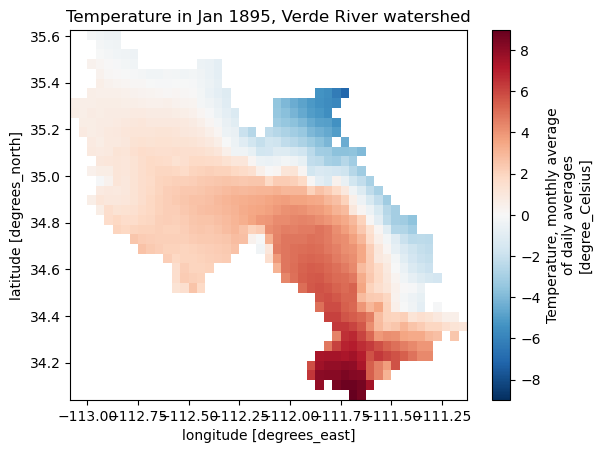

In [15]:
#plotting one of the clipped rasters (just to see if it looks right)
dat =Temp_Verde.isel(time=0) #filtering to keep only the 1st timepoint
dat.plot()
plt.title("Temperature in Jan 1895, Verde River watershed")
plt.show()

### c. Calculating mean temperature and total precipitation

In [137]:
Temp_Salt_mean = Temp_Salt.mean(dim=("lon", "lat"))
Precip_Salt_sum = Precip_Salt.sum(dim=("lon", "lat"))

Temp_Verde_mean = Temp_Verde.mean(dim=("lon", "lat"))
Precip_Verde_sum = Precip_Verde.sum(dim=("lon", "lat"))

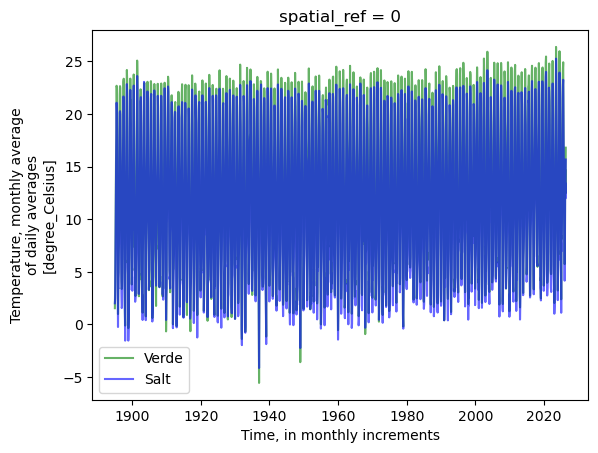

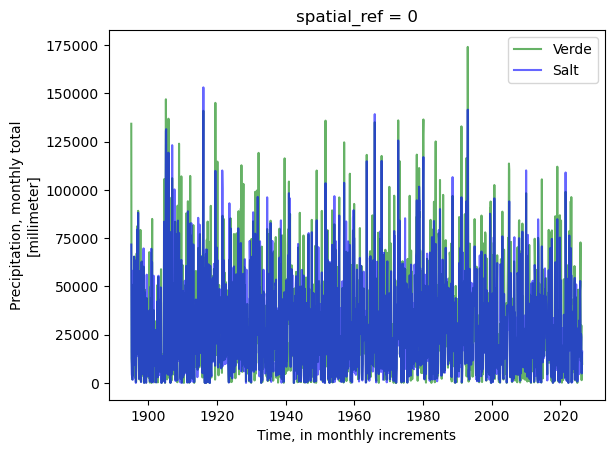

In [138]:
#plotting
Temp_Verde_mean.plot(alpha=0.6, color="green", label = "Verde")
Temp_Salt_mean.plot(alpha=0.6, color="blue", label="Salt")
plt.legend()
plt.show()

Precip_Verde_sum.plot(alpha=0.6, color="green", label = "Verde")
Precip_Salt_sum.plot(alpha=0.6, color="blue", label="Salt")
plt.legend()
plt.show()

### d. Saving

In [148]:
#creating a dataframe of climate data
Climate_dat_watersheds = pd.DataFrame({"Time":Temp_Salt_mean["time"].values,
                                      "Temp_Salt":Temp_Salt_mean.values,
                                      "Temp_Verde":Temp_Verde_mean.values,
                                      "Precip_Salt":Precip_Salt_sum.values,
                                      "Precip_Verde":Precip_Verde_sum.values})
Climate_dat_watersheds.head()

,Time,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde
0,1895-01-01,2.016537,1.548778,71669.250000,134251.937500
1,1895-02-01,2.488734,3.575411,17260.507812,12643.463867
2,1895-03-01,5.915051,7.470766,4439.287109,9704.540039
3,1895-04-01,9.875881,12.606539,2930.791016,1849.815430
4,1895-05-01,14.626182,15.331393,10896.961914,8430.880859


In [149]:
#saving as csv
Climate_dat_watersheds.to_csv("Data/FormattedData/Climate.csv", index = False)